<a href="https://colab.research.google.com/github/RexTabachnick/Machine-Unlearning-In-Applied-Contexts/blob/main/Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
%matplotlib inline
import pandas
import numpy as np# for data\
import tensorflow as tf
import sklearn
import matplotlib.pylab as plt
import keras
import tensorflow


In [3]:
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.applications.densenet import decode_predictions
from tensorflow.keras.applications.densenet import DenseNet121

In [4]:
### DOWNLOAD KAGGLE DATASET

!kaggle datasets download -d jessicali9530/celeba-dataset --path /content/celeba -q
!unzip -q /content/celeba/celeba-dataset.zip -d /content/celeba/

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other


In [5]:
### SHOW FILE CONTENT

import os

# See exactly what files are in your celeba folder
for root, dirs, files in os.walk('/content/celeba'):
    for f in files:
        print(os.path.join(root, f))

Streaming output truncated to the last 5000 lines.
/content/celeba/img_align_celeba/img_align_celeba/068113.jpg
/content/celeba/img_align_celeba/img_align_celeba/029369.jpg
/content/celeba/img_align_celeba/img_align_celeba/017279.jpg
/content/celeba/img_align_celeba/img_align_celeba/153062.jpg
/content/celeba/img_align_celeba/img_align_celeba/201274.jpg
/content/celeba/img_align_celeba/img_align_celeba/015262.jpg
/content/celeba/img_align_celeba/img_align_celeba/014895.jpg
/content/celeba/img_align_celeba/img_align_celeba/098957.jpg
/content/celeba/img_align_celeba/img_align_celeba/041747.jpg
/content/celeba/img_align_celeba/img_align_celeba/040063.jpg
/content/celeba/img_align_celeba/img_align_celeba/035347.jpg
/content/celeba/img_align_celeba/img_align_celeba/155101.jpg
/content/celeba/img_align_celeba/img_align_celeba/004839.jpg
/content/celeba/img_align_celeba/img_align_celeba/015678.jpg
/content/celeba/img_align_celeba/img_align_celeba/069085.jpg
/content/celeba/img_align_celeba/i

In [6]:
### SAMPLING DATA (SEPARATING GLASSES VS NON-GLASSES)

import pandas as pd
import os
import torch

IMG_DIR   = '/content/celeba/img_align_celeba/img_align_celeba/'
IMG_SIZE  = 64
BATCH_SIZE = 64
LATENT_DIM = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load attributes
attr_df = pd.read_csv('/content/celeba/list_attr_celeba.csv')

# attr_dr['attribute_name'] is the sub-array with data objects containing the attribute
# Ex: attr_dr['Brown eyes'] will return an array of image objects with the label "Brown eyes".

# CelebA uses -1/1 instead of 0/1 — convert to proper booleans
# 1 = has attribute, -1 = does not
# forget_mask is a grouping mask (distinction) of the images with the given "Eyeglasses" attribute
forget_mask = attr_df['Eyeglasses'] == 1
retain_mask  = attr_df['Eyeglasses'] != 1

# all images with glasses (to forget)
forget_df = attr_df[forget_mask].reset_index(drop=True)

# all images without glasses (to remember)
retain_df  = attr_df[retain_mask].sample(n=15000, random_state=42).reset_index(drop=True)

print(f"Forget set (with glasses): {len(forget_df)} images")
print(f"Retain set (no glasses):   {len(retain_df)} images")

Using device: cuda
Forget set (with glasses): 13193 images
Retain set (no glasses):   15000 images


In [7]:
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import torch

# Creating a class for the celebrity dataset
# Resizing the images and converting them to Tensors
class CelebAAttr(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.loc[idx, 'image_id']
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0  # ← dummy label, autoencoder doesn't use it

transform = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Converting image objects into CelebAAttr objects
forget_dataset = CelebAAttr(forget_df, IMG_DIR, transform)
retain_dataset  = CelebAAttr(retain_df,  IMG_DIR, transform)

# wrapping data in a DataLoader, which _____
forget_loader = DataLoader(forget_dataset, batch_size=BATCH_SIZE, shuffle=True)
retain_loader  = DataLoader(retain_dataset,  batch_size=BATCH_SIZE, shuffle=True)

# Combined loader for initial training (all images together)
from torch.utils.data import ConcatDataset
full_dataset = ConcatDataset([forget_dataset, retain_dataset])
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Loaders ready.")
print(f"Forget batches: {len(forget_loader)} | Retain batches: {len(retain_loader)}")

Loaders ready.
Forget batches: 207 | Retain batches: 235


In [8]:
import torch.nn as nn

# Defining the AutoEncoder Model
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 64→32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32→16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16→8
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# 8→4
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc_enc  = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_dec  = nn.Linear(latent_dim, 256 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.fc_enc(self.flatten(self.encoder(x)))
        decoded = self.decoder(self.fc_dec(encoded).view(-1, 256, 4, 4))
        return decoded

model = Autoencoder(latent_dim=LATENT_DIM).to(device)
print(f"Model ready. Params: {sum(p.numel() for p in model.parameters()):,}")

Model ready. Params: 2,432,835


In [9]:
# INITIAL TRAINING

import os

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_autoencoder(model, loader, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, _ in loader:
            images = images.to(device)
            recon  = model(images)
            loss   = criterion(recon, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.5f}")

train_autoencoder(model, full_loader, epochs=10)

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/AE_orig.pt')
print("Saved AE_orig.pt")

Epoch 1/10 | Loss: 0.02355
Epoch 2/10 | Loss: 0.00965
Epoch 3/10 | Loss: 0.00780
Epoch 4/10 | Loss: 0.00685
Epoch 5/10 | Loss: 0.00623
Epoch 6/10 | Loss: 0.00583
Epoch 7/10 | Loss: 0.00552
Epoch 8/10 | Loss: 0.00529
Epoch 9/10 | Loss: 0.00506
Epoch 10/10 | Loss: 0.00493
Saved AE_orig.pt


=== BEFORE UNLEARNING ===
Forget MSE (glasses): 0.00525
Retain MSE (no glasses): 0.00442


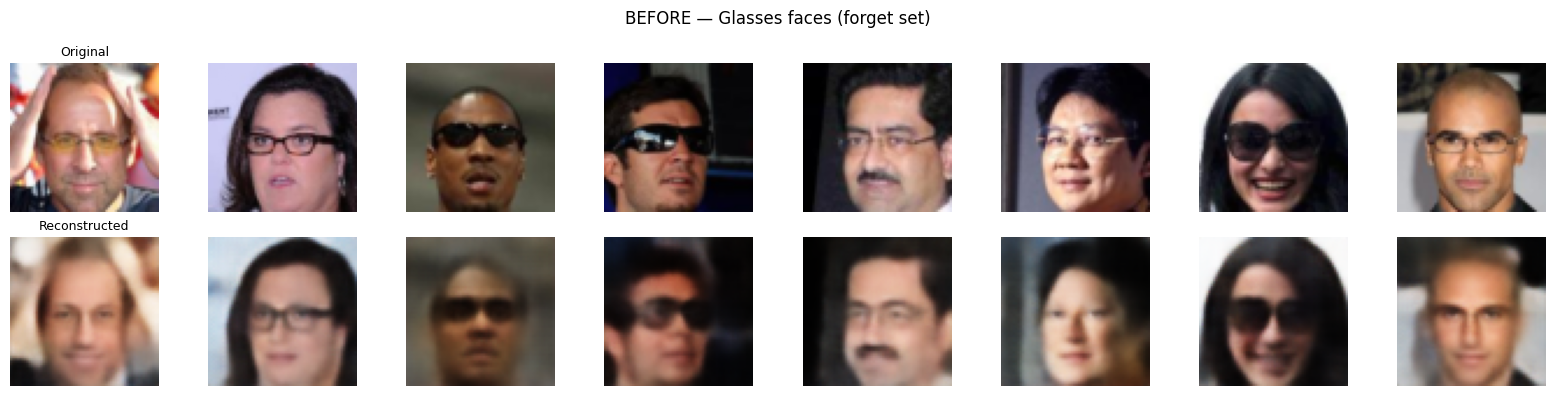

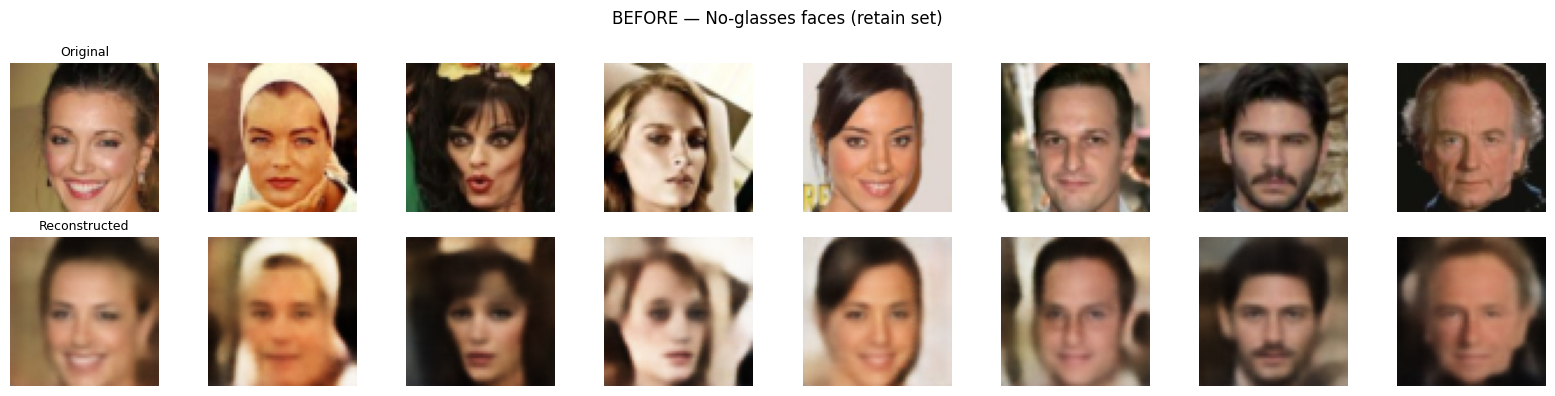

In [10]:
# INITIAL RECONSTRUCTIONS

import matplotlib.pyplot as plt

def show_reconstructions(model, loader, title="", n=8):
    model.eval() # testing, not training
    images, _ = next(iter(loader)) # grab 1 batch of images from loader (no labels)
    images = images[:n].to(device) # take the first 8 images --> GPU
    with torch.no_grad(): # not tracking gradients
        recons = model(images) # reconstruct images with Autoencoder
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4)) # create grid w/ 8 slots
    for i in range(n): # fill each slot w/ original + reconned image
        axes[0,i].imshow(images[i].cpu().permute(1,2,0).clamp(0,1))
        axes[0,i].axis('off')
        axes[1,i].imshow(recons[i].cpu().permute(1,2,0).clamp(0,1))
        axes[1,i].axis('off')

    # formatting
    axes[0,0].set_title('Original', fontsize=9)
    axes[1,0].set_title('Reconstructed', fontsize=9)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def compute_mse(model, loader):
    model.eval()
    total, count = 0, 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            total += criterion(model(images), images).item() * images.size(0)
            count += images.size(0)
    return total / count

print("=== BEFORE UNLEARNING ===")
forget_mse_before = compute_mse(model, forget_loader)
retain_mse_before = compute_mse(model, retain_loader)
print(f"Forget MSE (glasses): {forget_mse_before:.5f}")
print(f"Retain MSE (no glasses): {retain_mse_before:.5f}")

show_reconstructions(model, forget_loader, title="BEFORE — Glasses faces (forget set)")
show_reconstructions(model, retain_loader, title="BEFORE — No-glasses faces (retain set)")

In [11]:
# ORIGINAL STRATEGY: GRADIENT ASCENT ON FORGET SET

unlearn_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
unlearn_model.load_state_dict(torch.load('models/AE_orig.pt'))

# FIX 1: Lower LR — less aggressive per step
unlearn_optimizer = torch.optim.Adam(unlearn_model.parameters(), lr=2e-5)  # was 1e-4

forget_iter = iter(forget_loader)
retain_iter = iter(retain_loader)

GA_STEPS = 100  # FIX 2: Fewer steps — was 200

def safe_next(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        new_iter = iter(loader)
        return next(new_iter), new_iter

print("=== UNLEARNING (TUNED) ===")
for step in range(GA_STEPS):
    unlearn_model.train()

    # Gradient ASCENT on glasses
    (imgs, _), forget_iter = safe_next(forget_iter, forget_loader)
    imgs = imgs.to(device)
    unlearn_optimizer.zero_grad()
    (-criterion(unlearn_model(imgs), imgs)).backward()
    unlearn_optimizer.step()

    # FIX 3: TWO retain steps per GA step — better protection
    for _ in range(2):
        (imgs, _), retain_iter = safe_next(retain_iter, retain_loader)
        imgs = imgs.to(device)
        unlearn_optimizer.zero_grad()
        criterion(unlearn_model(imgs), imgs).backward()
        unlearn_optimizer.step()

    if step % 20 == 0 or step == GA_STEPS - 1:
        f = compute_mse(unlearn_model, forget_loader)
        r = compute_mse(unlearn_model, retain_loader)
        print(f"Step {step:3d} | Forget MSE: {f:.5f} | Retain MSE: {r:.5f}")

=== UNLEARNING (TUNED) ===
Step   0 | Forget MSE: 0.00528 | Retain MSE: 0.00444
Step  20 | Forget MSE: 0.00531 | Retain MSE: 0.00426
Step  40 | Forget MSE: 0.00693 | Retain MSE: 0.00456
Step  60 | Forget MSE: 0.01470 | Retain MSE: 0.00612
Step  80 | Forget MSE: 0.03001 | Retain MSE: 0.00897
Step  99 | Forget MSE: 0.05628 | Retain MSE: 0.01336


In [14]:
# NEW STRATEGY 1: Random Noise Targeting
# Instead of: loss = -MSE(model(forget_imgs), forget_imgs)   ← GA
# Do this:    loss =  MSE(model(forget_imgs), random_noise)  ← push toward noise

def unlearn_noise_targeting(model, forget_loader, retain_loader, steps=150):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    forget_iter = iter(forget_loader)
    retain_iter = iter(retain_loader)

    for step in range(steps):
        model.train()

        # --- FORGET STEP: push glasses faces toward random noise ---
        (imgs, _), forget_iter = safe_next(forget_iter, forget_loader)
        imgs = imgs.to(device)
        noise_target = torch.rand_like(imgs)  # random noise, same shape as image
        optimizer.zero_grad()
        loss_forget = criterion(model(imgs), noise_target)  # learn to output noise
        loss_forget.backward()
        optimizer.step()

        # --- RETAIN STEP: keep non-glasses faces sharp (2x per forget step) ---
        for _ in range(2):
            (imgs, _), retain_iter = safe_next(retain_iter, retain_loader)
            imgs = imgs.to(device)
            optimizer.zero_grad()
            criterion(model(imgs), imgs).backward()
            optimizer.step()

        if step % 25 == 0 or step == steps - 1:
            f = compute_mse(model, forget_loader)
            r = compute_mse(model, retain_loader)
            print(f"Step {step:3d} | Forget MSE: {f:.5f} | Retain MSE: {r:.5f}")


new_unlearn_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
new_unlearn_model.load_state_dict(torch.load('models/AE_orig.pt'))

unlearn_noise_targeting(new_unlearn_model, forget_loader, retain_loader, steps=150)


Step   0 | Forget MSE: 0.00698 | Retain MSE: 0.00606
Step  25 | Forget MSE: 0.01615 | Retain MSE: 0.01172
Step  50 | Forget MSE: 0.02193 | Retain MSE: 0.01040
Step  75 | Forget MSE: 0.03554 | Retain MSE: 0.00942
Step 100 | Forget MSE: 0.04797 | Retain MSE: 0.00925
Step 125 | Forget MSE: 0.05180 | Retain MSE: 0.00832
Step 149 | Forget MSE: 0.05721 | Retain MSE: 0.00840


In [19]:
good_teacher = Autoencoder(latent_dim=LATENT_DIM).to(device)
good_teacher.load_state_dict(torch.load('models/AE_orig.pt'))
for p in good_teacher.parameters():
    p.requires_grad = False
good_teacher.eval()

student = Autoencoder(latent_dim=LATENT_DIM).to(device)
student.load_state_dict(torch.load('models/AE_orig.pt'))

optimizer = torch.optim.Adam(student.parameters(), lr=5e-5)  # lower LR
forget_iter = iter(forget_loader)
retain_iter = iter(retain_loader)

W_FORGET = 1.0
W_RETAIN  = 5.0   # retain dominates — protects quality

STEPS = 150
print("=== BAD TEACHER V2 ===")
for step in range(STEPS):
    student.train()

    # Forget: target = the same batch but SHUFFLED → each face gets wrong reconstruction
    (f_imgs, _), forget_iter = safe_next(forget_iter, forget_loader)
    f_imgs = f_imgs.to(device)
    shuffled = f_imgs[torch.randperm(f_imgs.size(0))]  # wrong face as target
    loss_forget = W_FORGET * criterion(student(f_imgs), shuffled.detach())

    # Retain: student must match good teacher exactly
    (r_imgs, _), retain_iter = safe_next(retain_iter, retain_loader)
    r_imgs = r_imgs.to(device)
    with torch.no_grad():
        good_target = good_teacher(r_imgs)
    loss_retain = W_RETAIN * criterion(student(r_imgs), good_target)

    optimizer.zero_grad()
    (loss_forget + loss_retain).backward()
    optimizer.step()

    if step % 25 == 0 or step == STEPS - 1:
        f = compute_mse(student, forget_loader)
        r = compute_mse(student, retain_loader)
        print(f"Step {step:3d} | Forget MSE: {f:.5f} | Retain MSE: {r:.5f}")

torch.save(student.state_dict(), 'models/AE_badteacher_v2.pt')

=== BAD TEACHER V2 ===
Step   0 | Forget MSE: 0.00546 | Retain MSE: 0.00463
Step  25 | Forget MSE: 0.00789 | Retain MSE: 0.00644
Step  50 | Forget MSE: 0.00844 | Retain MSE: 0.00653
Step  75 | Forget MSE: 0.00883 | Retain MSE: 0.00647
Step 100 | Forget MSE: 0.00933 | Retain MSE: 0.00642
Step 125 | Forget MSE: 0.01043 | Retain MSE: 0.00657
Step 149 | Forget MSE: 0.01150 | Retain MSE: 0.00636



========== RESULTS ==========
                                   Before      After
Forget MSE (glasses)              0.00525    0.05833
Retain MSE (no glasses)           0.00442    0.01427

Forget MSE rose by:  1010.7%  ← want this BIG
Retain MSE rose by:  223.1%   ← want this SMALL


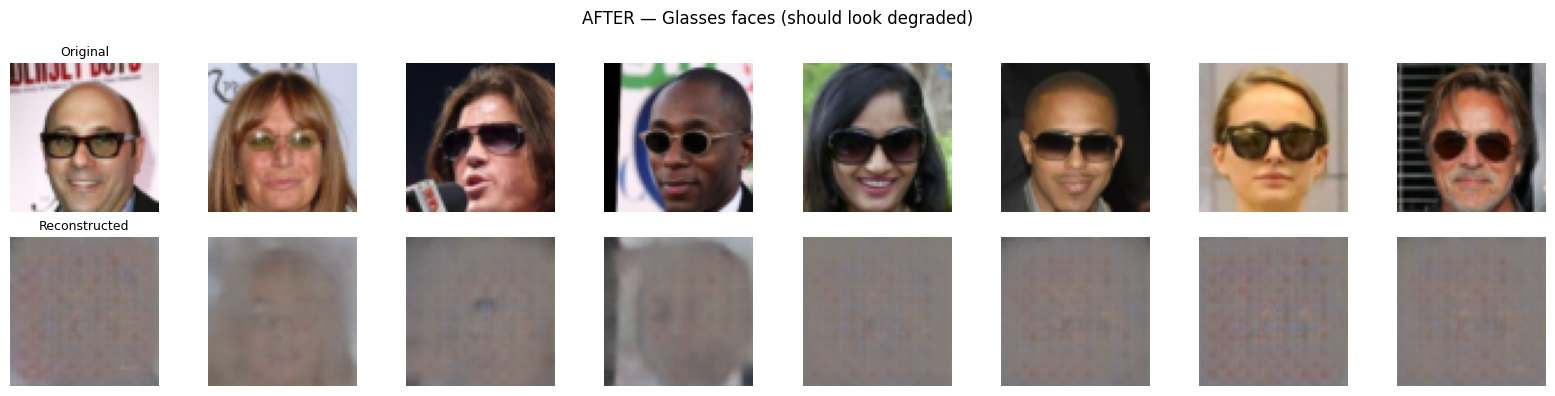

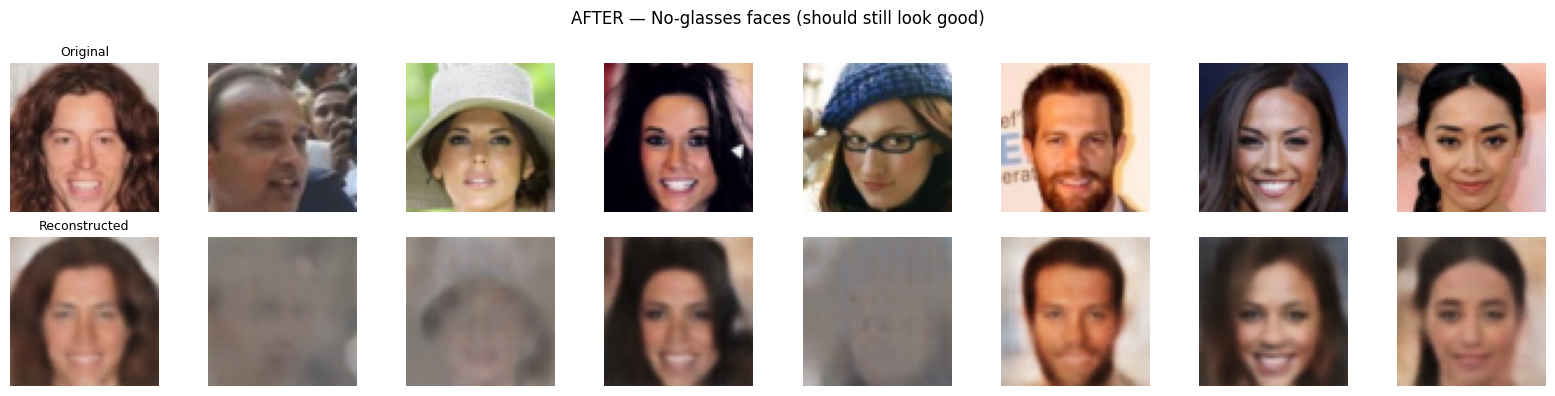

In [18]:
forget_mse_after = compute_mse(student, forget_loader)
retain_mse_after  = compute_mse(student, retain_loader)

print("\n========== RESULTS ==========")
print(f"{'':30} {'Before':>10} {'After':>10}")
print(f"{'Forget MSE (glasses)':30} {forget_mse_before:>10.5f} {forget_mse_after:>10.5f}")
print(f"{'Retain MSE (no glasses)':30} {retain_mse_before:>10.5f} {retain_mse_after:>10.5f}")
print(f"\nForget MSE rose by:  {(forget_mse_after/forget_mse_before-1)*100:.1f}%  ← want this BIG")
print(f"Retain MSE rose by:  {(retain_mse_after/retain_mse_before-1)*100:.1f}%   ← want this SMALL")

show_reconstructions(student, forget_loader, title="AFTER — Glasses faces (should look degraded)")
show_reconstructions(student, retain_loader, title="AFTER — No-glasses faces (should still look good)")